In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="muted")

## Get The Dataset

In [ ]:
import yfinance as yf
from datetime import datetime

now = datetime.now()
start = datetime(now.year - 10, now.month, now.day)
end = now

ticker = "GOOG"
df = yf.download(ticker, start, end)
df.head()

### Data Cleansing

In [ ]:
df.isna().sum()

In [ ]:
df.dropna(inplace=True)
df.columns

In [ ]:
df.columns = df.columns.droplevel(1)
df.columns.names = [None]
df.head()

## Feature Engineering & Visualization

Text(0.5, 0, 'Days')

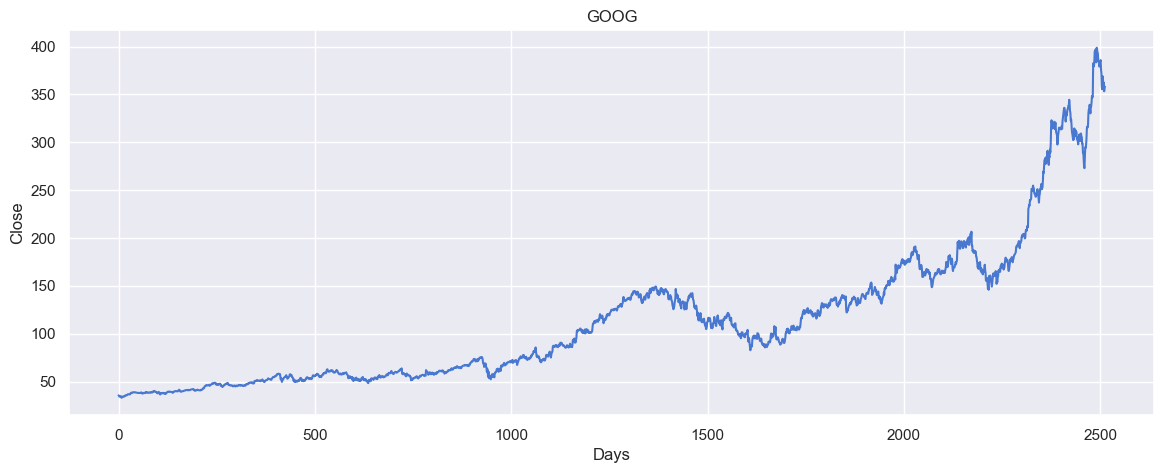

In [96]:
plt.figure(figsize=(14, 5))
sns.lineplot(df, x=df.index, y="Close")
plt.title("GOOG")
plt.xlabel("Days")

In [97]:
df["MA_100"] = df.Close.rolling(100).mean()
df["MA_200"] = df.Close.rolling(200).mean()
df.head(102)

,Date,Close,High,Low,Open,Volume,MA_100,MA_200
0,2016-06-15,35.631844,35.833069,35.552049,35.635810,24290000,NaN,NaN
1,2016-06-16,35.207584,35.519335,34.855684,35.433093,39650000,NaN,NaN
2,2016-06-17,34.283730,35.131260,34.121759,35.122832,68048000,NaN,NaN
3,2016-06-20,34.382366,34.817033,34.367498,34.633153,41650000,NaN,NaN
4,2016-06-21,34.492889,34.831404,34.298104,34.614812,29312000,NaN,NaN
...,...,...,...,...,...,...,...,...
97,2016-11-01,38.838078,39.129507,38.438104,38.802393,48128000,NaN,NaN
98,2016-11-02,38.099091,38.740931,37.838884,38.569938,37448000,NaN,NaN
99,2016-11-03,37.773464,38.161050,37.619820,38.027227,38864000,37.561452,NaN
100,2016-11-04,37.768013,38.181368,37.200068,37.204976,42696000,37.582814,NaN


Text(0, 0.5, 'Moving Average')

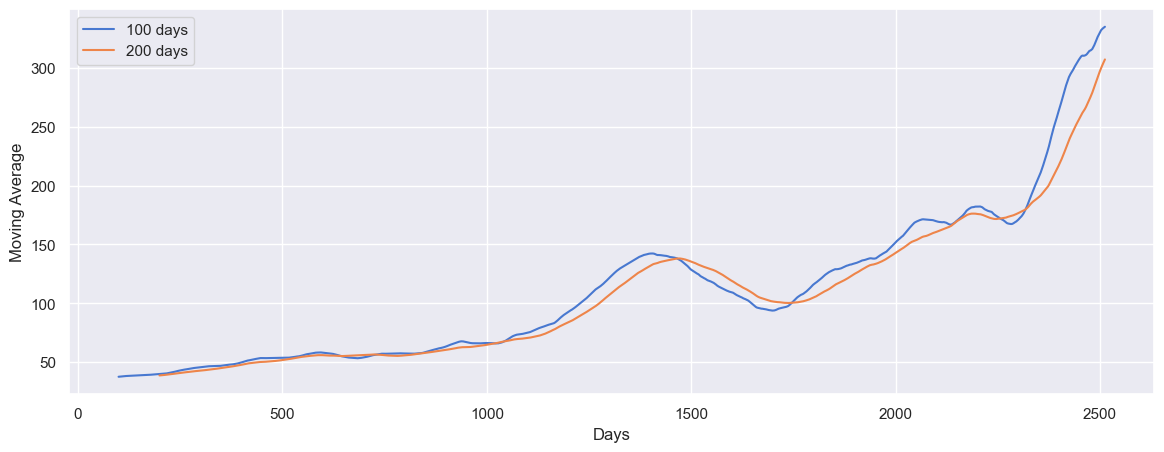

In [98]:
plt.figure(figsize=(14, 5))
sns.lineplot(df, x=df.index, y="MA_100", label="100 days")
sns.lineplot(df, x=df.index, y="MA_200", label="200 days")
plt.xlabel("Days")
plt.ylabel("Moving Average")

In [99]:
df["pct_change"] = df.Close.pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,MA_100,MA_200,pct_change
0,2016-06-15,35.631844,35.833069,35.552049,35.635810,24290000,NaN,NaN,NaN
1,2016-06-16,35.207584,35.519335,34.855684,35.433093,39650000,NaN,NaN,-0.011907
2,2016-06-17,34.283730,35.131260,34.121759,35.122832,68048000,NaN,NaN,-0.026240
3,2016-06-20,34.382366,34.817033,34.367498,34.633153,41650000,NaN,NaN,0.002877
4,2016-06-21,34.492889,34.831404,34.298104,34.614812,29312000,NaN,NaN,0.003215


Text(0, 0.5, 'Percentage Change')

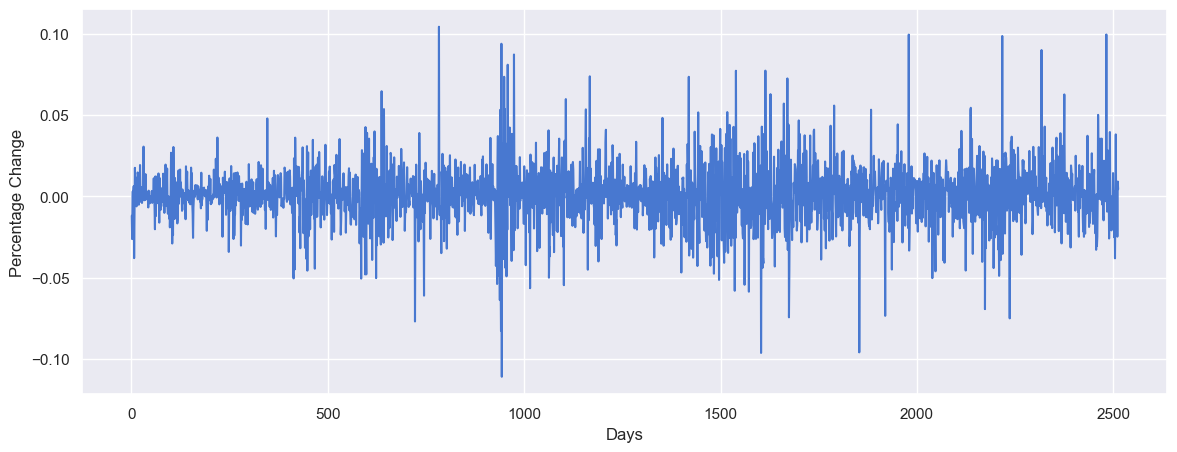

In [100]:
plt.figure(figsize=(14, 5))
sns.lineplot(df, x=df.index, y="pct_change")
plt.xlabel("Days")
plt.ylabel("Percentage Change")

## Data Preproccessing

In [101]:
df.shape

(2513, 9)

In [102]:
df.Close

0        35.631844
1        35.207584
2        34.283730
3        34.382366
4        34.492889
           ...    
2508    361.170013
2509    362.290009
2510    353.320007
2511    356.559998
2512    358.160004
Name: Close, Length: 2513, dtype: float64

In [103]:
from math import floor
# 30% test size
data = pd.DataFrame(df.Close)
p = 0.3
index = floor(len(data) * (1 - p))

train_data = data.iloc[:index]
test_data = data.iloc[index:]

print(train_data.shape, test_data.shape)

(1759, 1) (754, 1)


### Scaling

In [104]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
train_data = scaler.fit_transform(train_data)

### Data Splitting

In [105]:
x_train, y_train = [], []
for i in range(100, train_data.shape[0]):
    x_train.append(train_data[i-100 : i])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [106]:
x_train.shape

(1659, 100, 1)

## Modeling

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(128, activation="tanh", return_sequences=True))
model.add(LSTM(64))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

In [ ]:
model.fit(x_train, y_train, epochs=50)
model.save("./stock-perdictor.keras")

In [109]:
from keras.models import load_model
model = load_model("./stock-perdictor.keras")

In [110]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

## Prediction

In [ ]:
from sklearn.model_selection import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
test_data = scaler.fit_transform(test_data)

In [125]:
test_data[:5]

array([[0.02620457],
       [0.0264848 ],
       [0.02630962],
       [0.0312493 ],
       [0.02518861]])

In [ ]:
test_data = np.concat([train_data[-100:], test_data])
test_data.shape

(854, 1)

In [114]:
x_test, y_test = [], []
for i in range(100, test_data.shape[0]):
    x_test.append(test_data[i-100 : i])
    y_test.append(test_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [115]:
y_pred = model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


## Evaluation

In [116]:
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

In [ ]:
y_test

array([127.45623779, 129.23060608, 130.30116272, 131.2428894 ,
       132.09532166, 130.5390625 , 132.8883667 , 132.47201538,
       134.24636841, 135.18807983, 137.48780823, 135.74320984,
       136.71461487, 137.40852356, 138.79627991, 137.01199341,
       136.84350586, 137.40852356, 135.207901  , 132.74957275,
       132.15486145, 129.48835754, 131.23295593, 130.28132629,
       137.23999023, 135.44580078, 133.52275085, 132.47201538,
       132.7991333 , 132.03588867, 132.67028809, 135.99099731,
       136.89306641, 138.43943787, 140.56071472, 141.47267151,
       141.57182312, 140.20385742, 140.04527283, 139.69831848,
       138.34030151, 139.13328552, 136.83357239, 136.18925476,
       139.30181885, 141.31408691, 142.54325867, 142.41438293,
       142.97940063, 142.82081604, 141.64120483, 143.7228241 ,
       146.67678833, 146.41906738, 147.38056946, 149.03598022,
       152.29725647, 152.44592285, 153.48675537, 151.71240234,
       140.56071472, 141.46276855, 142.28552246, 143.66

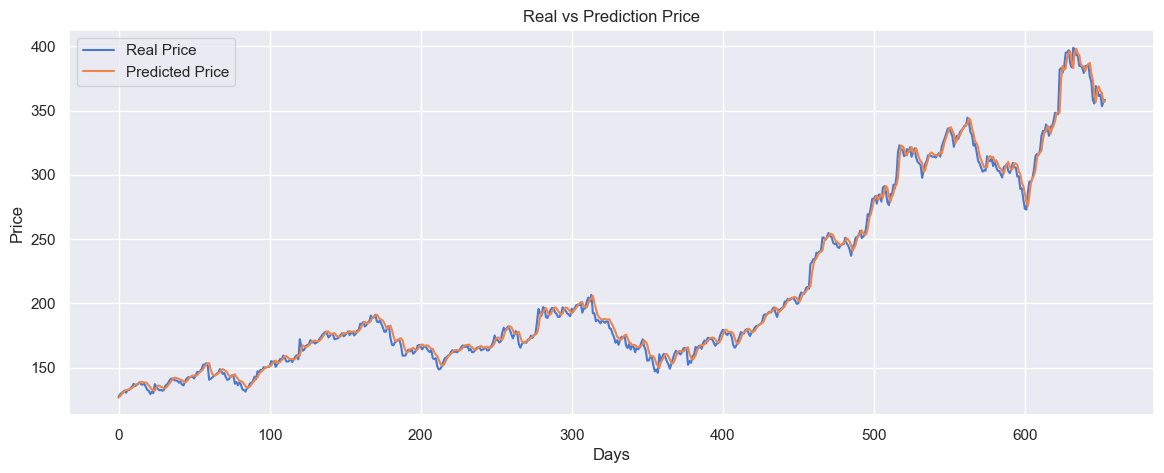

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test, label="Real Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Real vs Prediction Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

Zoom in the plot

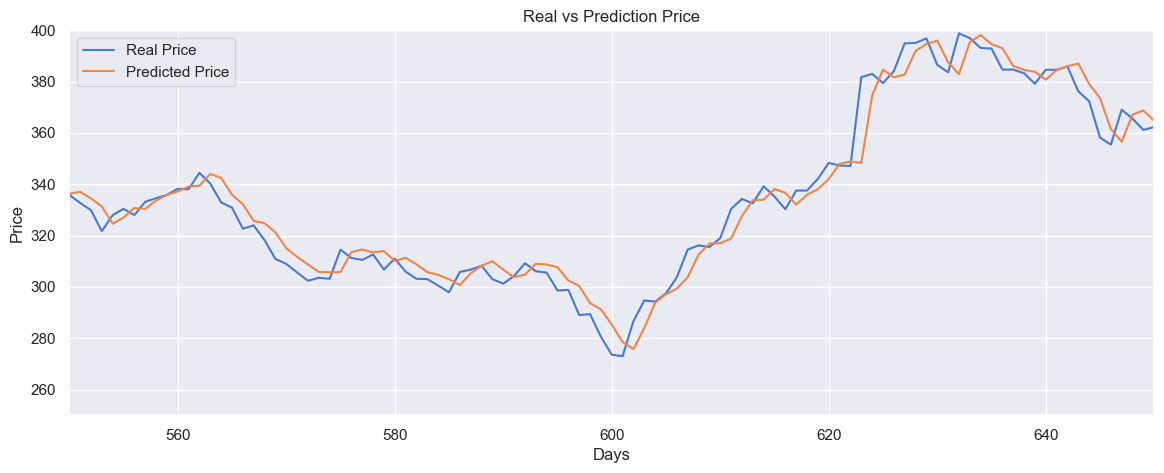

In [124]:
plt.figure(figsize=(14, 5))
plt.plot(y_test, label="Real Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Real vs Prediction Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.xlim(550, 650)
plt.ylim(250, 400)
plt.legend()

In [119]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"{mse = }")
print(f"{rmse = }")
print(f"{r2 = }")

mse = 21.284431047299446
rmse = np.float64(4.61350528853056)
r2 = 0.9957869993176359
